In [1]:
import pandas as pd
import numpy as np

# Load both cleaned datasets
ae = pd.read_csv('../data/processed/ae_clean.csv', parse_dates=['date'])
sickness = pd.read_csv('../data/processed/sickness_trust_clean.csv', parse_dates=['date'])

# Calculate A&E performance % per trust per month
ae['perf_pct'] = (
    (ae['A&E attendances Type 1'] - ae['Attendances over 4hrs Type 1']) /
    ae['A&E attendances Type 1'].replace(0, np.nan) * 100
)

# Keep only the columns we need
ae_clean = ae[['date', 'Org Code', 'Org name', 'Parent Org', 'perf_pct']].copy()
ae_clean.columns = ['date', 'org_code', 'org_name', 'region', 'perf_pct']
ae_clean = ae_clean.dropna(subset=['perf_pct'])

print("A&E clean rows:", len(ae_clean))
print("Sickness rows:", len(sickness))
print("A&E date range:", ae_clean['date'].min().strftime('%b %Y'), "to", ae_clean['date'].max().strftime('%b %Y'))

A&E clean rows: 5869
Sickness rows: 7042
A&E date range: Apr 2022 to Mar 2026


In [2]:
# Build the risk scoring function
# For each trust, look at the last 3 months of data
# Calculate trend direction for sickness and A&E performance

def calculate_trend(values):
    """Returns 'rising', 'falling', or 'stable' based on last 3 values"""
    if len(values) < 2:
        return 'stable'
    recent = values.tail(3).values
    if recent[-1] > recent[0]:
        return 'rising'
    elif recent[-1] < recent[0]:
        return 'falling'
    else:
        return 'stable'

def assign_risk_flag(sickness_trend, perf_trend):
    """
    RED:   sickness rising AND performance falling
    AMBER: sickness rising OR performance falling but not both
    GREEN: neither trending negatively
    """
    if sickness_trend == 'rising' and perf_trend == 'falling':
        return 'RED'
    elif sickness_trend == 'rising' or perf_trend == 'falling':
        return 'AMBER'
    else:
        return 'GREEN'

print("Risk scoring functions defined.")
print("Logic:")
print("  RED   = sickness rising AND A&E performance falling")
print("  AMBER = sickness rising OR A&E performance falling")
print("  GREEN = neither trending negatively")

Risk scoring functions defined.
Logic:
  RED   = sickness rising AND A&E performance falling
  AMBER = sickness rising OR A&E performance falling
  GREEN = neither trending negatively


In [3]:
# Apply risk scoring to all trusts
# Only trusts that appear in BOTH datasets get a risk flag

# Get the overlapping date range
overlap_start = sickness['date'].min()
ae_overlap = ae_clean[ae_clean['date'] >= overlap_start]

# Get list of trusts in both datasets
ae_trusts = set(ae_clean['org_code'].unique())
sick_trusts = set(sickness['ORG_CODE'].unique())
common_trusts = ae_trusts.intersection(sick_trusts)

print("Trusts in A&E data:", len(ae_trusts))
print("Trusts in sickness data:", len(sick_trusts))
print("Trusts in both datasets:", len(common_trusts))

# Build risk scores for each trust
results = []

for trust_code in common_trusts:
    ae_trust = ae_overlap[ae_overlap['org_code'] == trust_code].sort_values('date')
    sick_trust = sickness[sickness['ORG_CODE'] == trust_code].sort_values('date')
    
    if len(ae_trust) < 2 or len(sick_trust) < 2:
        continue
    
    org_name = ae_trust['org_name'].iloc[-1]
    region = ae_trust['region'].iloc[-1]
    
    sickness_trend = calculate_trend(sick_trust['sickness_rate'])
    perf_trend = calculate_trend(ae_trust['perf_pct'])
    risk_flag = assign_risk_flag(sickness_trend, perf_trend)
    
    latest_sickness = sick_trust['sickness_rate'].iloc[-1]
    latest_perf = ae_trust['perf_pct'].iloc[-1]
    
    results.append({
        'org_code': trust_code,
        'org_name': org_name,
        'region': region,
        'latest_sickness_pct': round(latest_sickness, 2),
        'latest_ae_perf_pct': round(latest_perf, 2),
        'sickness_trend': sickness_trend,
        'ae_perf_trend': perf_trend,
        'risk_flag': risk_flag
    })

risk_df = pd.DataFrame(results)
print("\nRisk flags assigned:", len(risk_df))
print("\nRisk flag distribution:")
print(risk_df['risk_flag'].value_counts())

Trusts in A&E data: 125
Trusts in sickness data: 287
Trusts in both datasets: 122

Risk flags assigned: 122

Risk flag distribution:
risk_flag
AMBER    89
GREEN    30
RED       3
Name: count, dtype: int64


In [4]:
# Show the RED flag trusts
print("RED FLAG TRUSTS - Immediate concern:")
print("Both sickness rising AND A&E performance falling")
print()
red_trusts = risk_df[risk_df['risk_flag'] == 'RED'].sort_values('latest_ae_perf_pct')
print(red_trusts[['org_name', 'region', 'latest_sickness_pct', 'latest_ae_perf_pct', 'sickness_trend', 'ae_perf_trend']].to_string())
print()
print("AMBER FLAG TRUSTS - Watch list (top 10 by lowest A&E performance):")
amber_trusts = risk_df[risk_df['risk_flag'] == 'AMBER'].sort_values('latest_ae_perf_pct').head(10)
print(amber_trusts[['org_name', 'region', 'latest_sickness_pct', 'latest_ae_perf_pct']].to_string())

RED FLAG TRUSTS - Immediate concern:
Both sickness rising AND A&E performance falling

                                          org_name                   region  latest_sickness_pct  latest_ae_perf_pct sickness_trend ae_perf_trend
104  NORTH MIDDLESEX UNIVERSITY HOSPITAL NHS TRUST       NHS ENGLAND LONDON                 4.57               41.54         rising       falling
22          SURREY AND SUSSEX HEALTHCARE NHS TRUST  NHS ENGLAND SOUTH EAST                  4.77               54.85         rising       falling
34       GUY'S AND ST THOMAS' NHS FOUNDATION TRUST       NHS ENGLAND LONDON                 5.04               59.96         rising       falling

AMBER FLAG TRUSTS - Watch list (top 10 by lowest A&E performance):
                                             org_name                                 region  latest_sickness_pct  latest_ae_perf_pct
93            UNIVERSITY HOSPITALS PLYMOUTH NHS TRUST                NHS ENGLAND SOUTH WEST                  6.64              

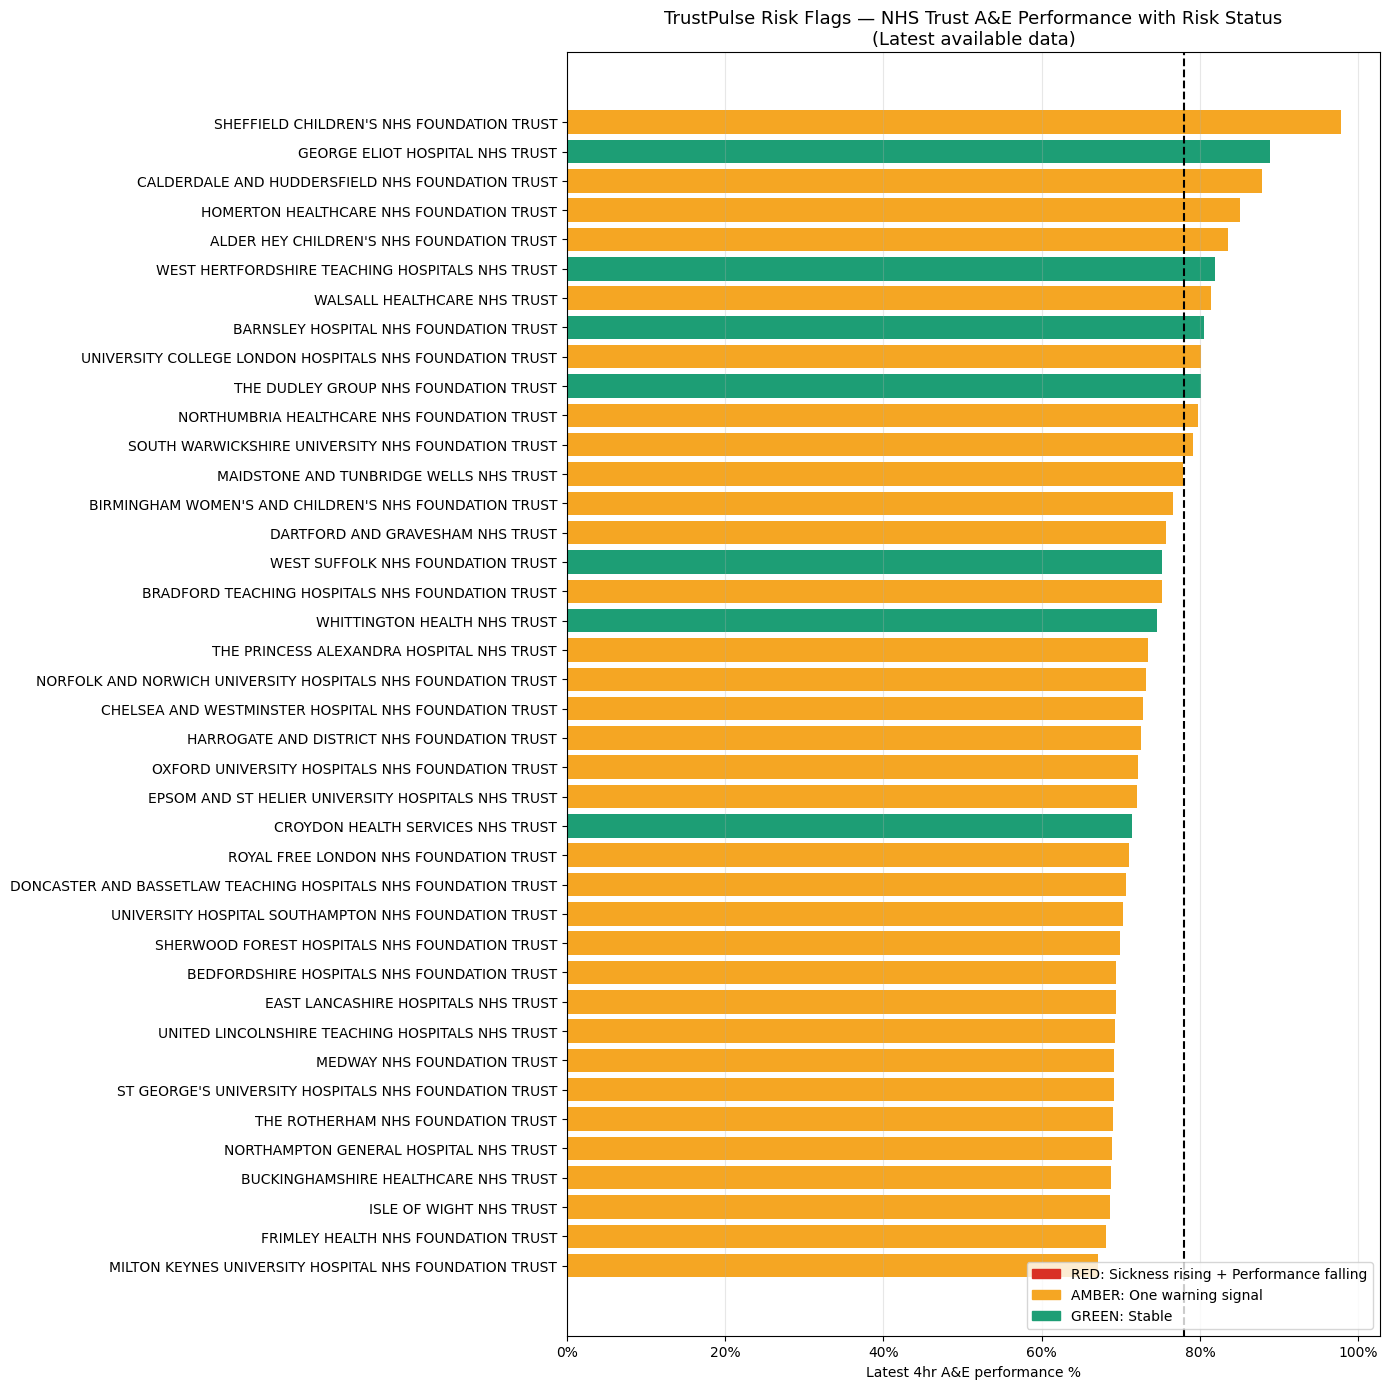

Chart saved.


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Sort by A&E performance for a clean visual
risk_sorted = risk_df.sort_values('latest_ae_perf_pct', ascending=True).tail(40)

# Colour map for risk flags
color_map = {'RED': '#d93025', 'AMBER': '#f5a623', 'GREEN': '#1d9e75'}
colors = [color_map[flag] for flag in risk_sorted['risk_flag']]

fig, ax = plt.subplots(figsize=(14, 14))
bars = ax.barh(risk_sorted['org_name'], risk_sorted['latest_ae_perf_pct'], color=colors)

ax.axvline(x=78, color='black', linestyle='--', linewidth=1.5, label='78% target')
ax.set_title('TrustPulse Risk Flags — NHS Trust A&E Performance with Risk Status\n(Latest available data)', fontsize=13)
ax.set_xlabel('Latest 4hr A&E performance %')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Legend
red_patch = mpatches.Patch(color='#d93025', label='RED: Sickness rising + Performance falling')
amber_patch = mpatches.Patch(color='#f5a623', label='AMBER: One warning signal')
green_patch = mpatches.Patch(color='#1d9e75', label='GREEN: Stable')
ax.legend(handles=[red_patch, amber_patch, green_patch], loc='lower right')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../static/chart_risk_flags.png', dpi=150)
plt.show()
print("Chart saved.")

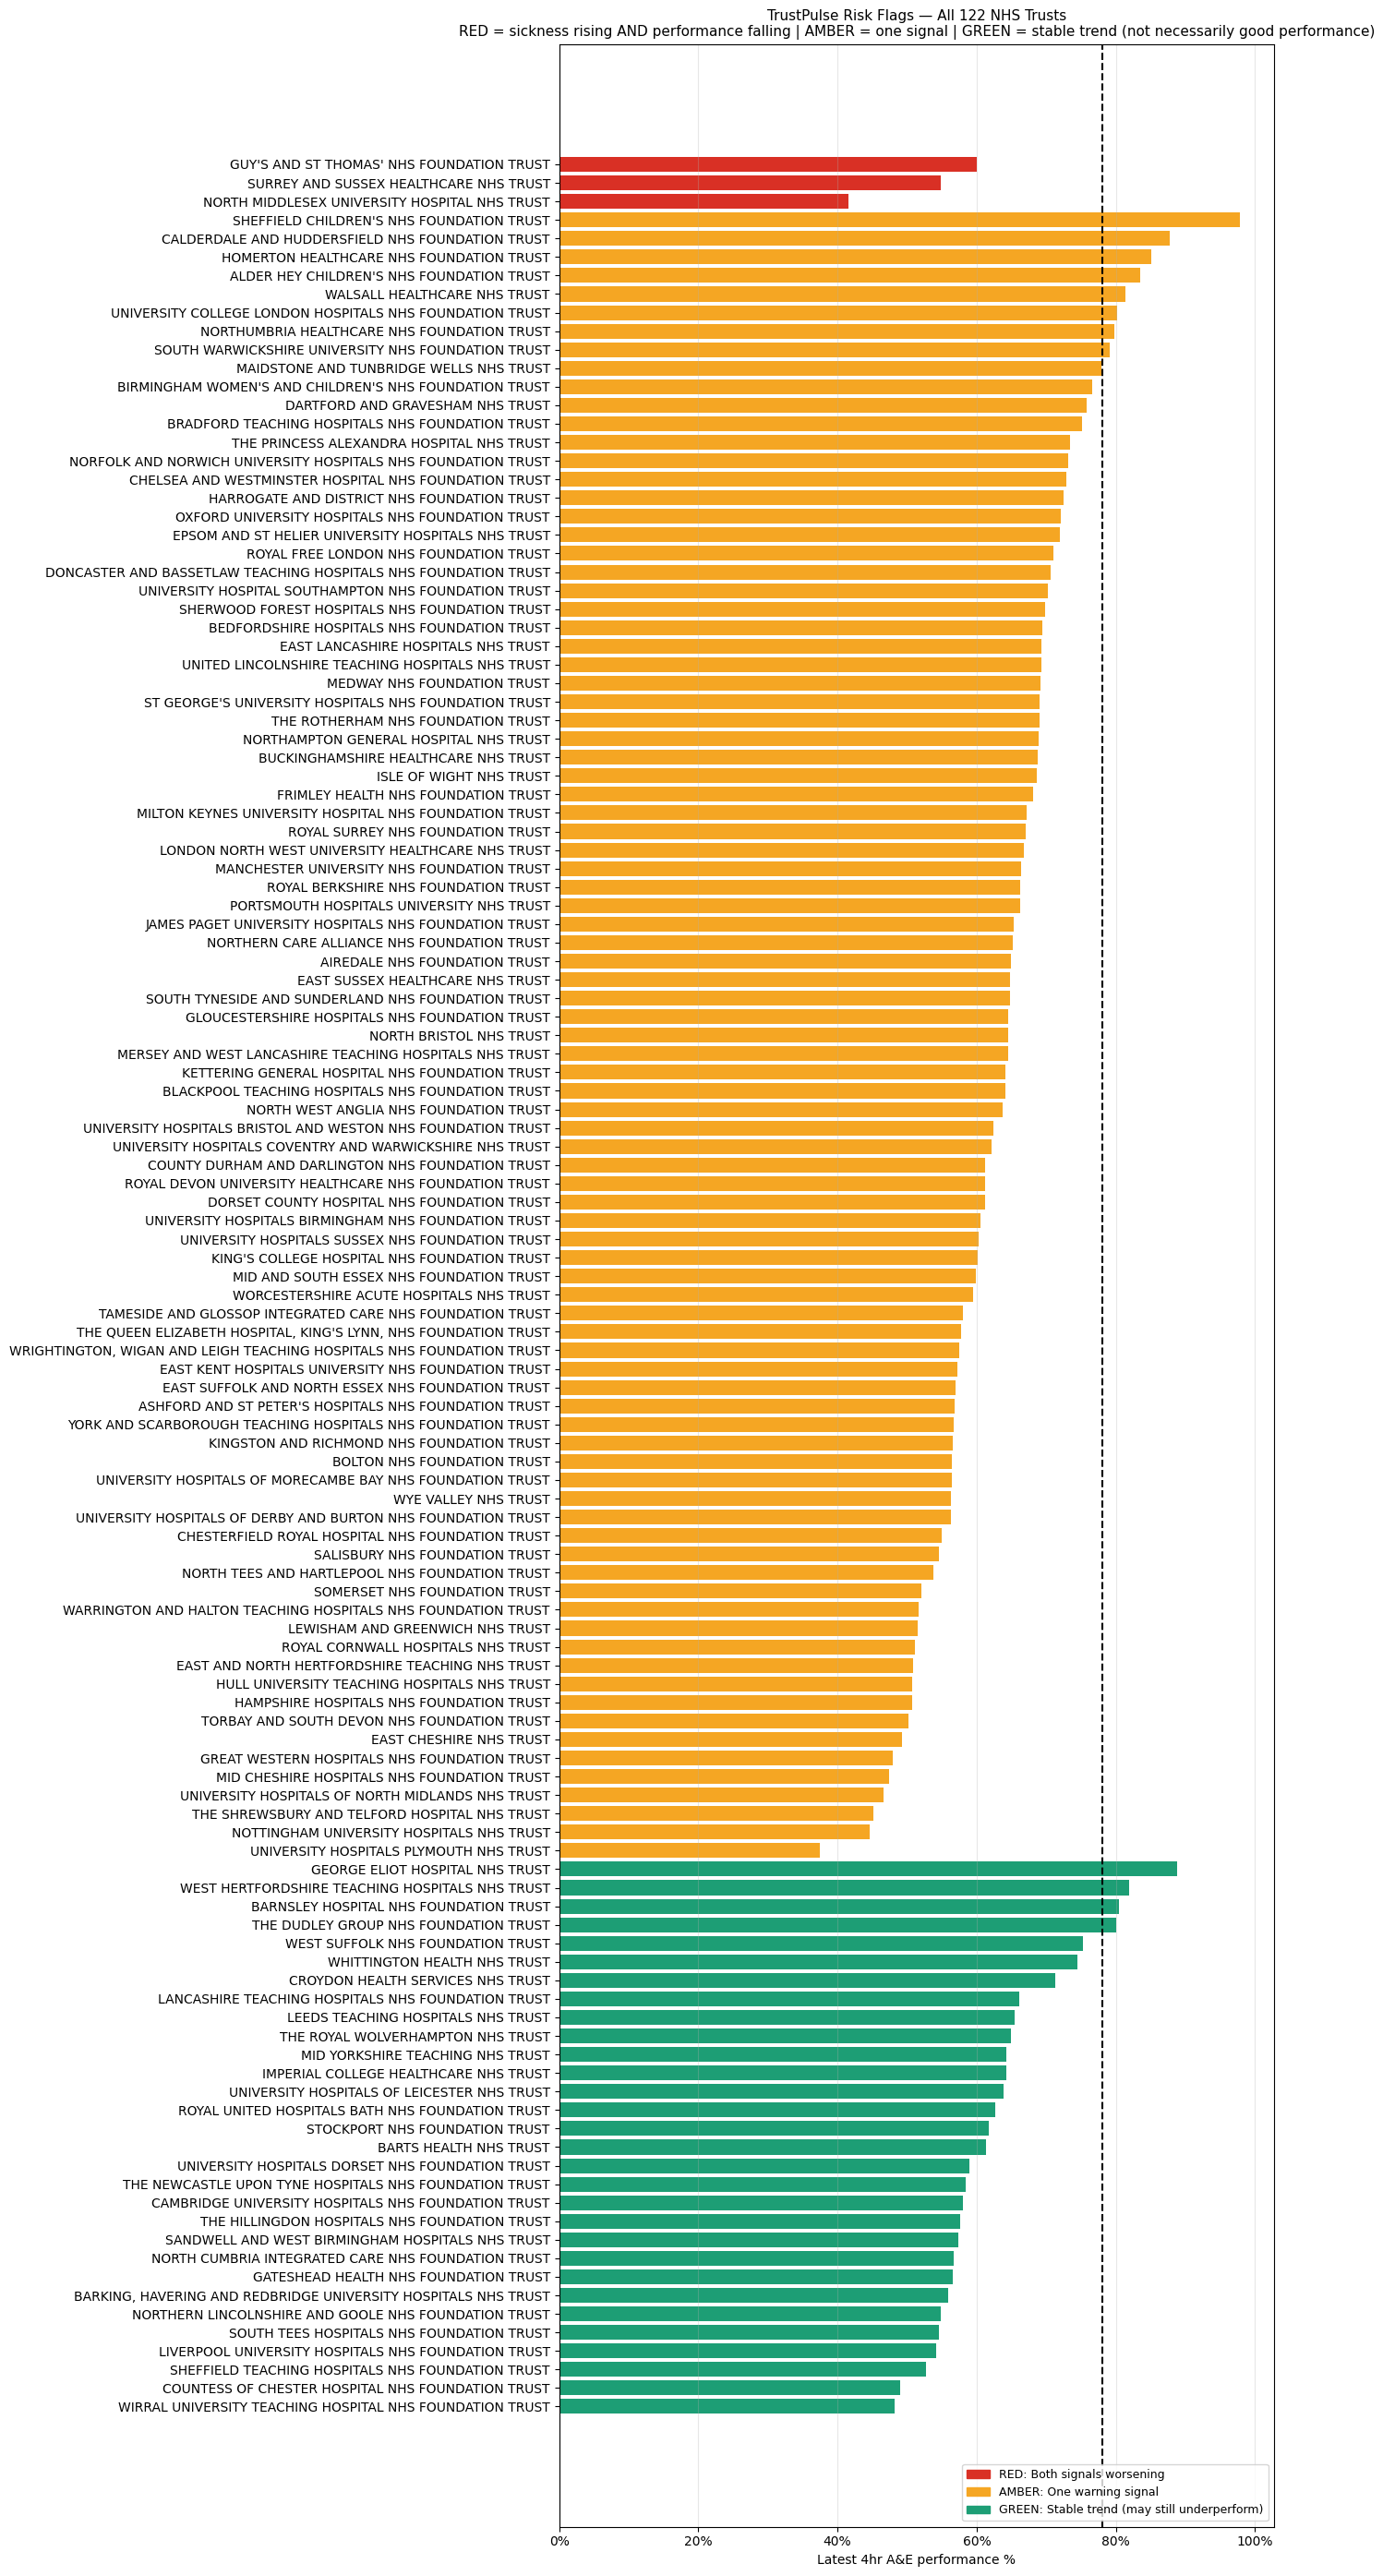

Chart saved.


In [6]:
# Fixed chart - all trusts, sorted by risk flag then performance
# RED first, then AMBER, then GREEN within each group

risk_df['flag_order'] = risk_df['risk_flag'].map({'RED': 0, 'AMBER': 1, 'GREEN': 2})
risk_sorted_all = risk_df.sort_values(['flag_order', 'latest_ae_perf_pct'], ascending=[False, True])

color_map = {'RED': '#d93025', 'AMBER': '#f5a623', 'GREEN': '#1d9e75'}
colors = [color_map[flag] for flag in risk_sorted_all['risk_flag']]

fig, ax = plt.subplots(figsize=(14, 28))
ax.barh(risk_sorted_all['org_name'], risk_sorted_all['latest_ae_perf_pct'], color=colors)

ax.axvline(x=78, color='black', linestyle='--', linewidth=1.5, label='78% NHS target')
ax.set_title('TrustPulse Risk Flags — All 122 NHS Trusts\n'
             'RED = sickness rising AND performance falling | '
             'AMBER = one signal | GREEN = stable trend (not necessarily good performance)',
             fontsize=11)
ax.set_xlabel('Latest 4hr A&E performance %')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

red_patch = mpatches.Patch(color='#d93025', label='RED: Both signals worsening')
amber_patch = mpatches.Patch(color='#f5a623', label='AMBER: One warning signal')
green_patch = mpatches.Patch(color='#1d9e75', label='GREEN: Stable trend (may still underperform)')
ax.legend(handles=[red_patch, amber_patch, green_patch], loc='lower right', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../static/chart_risk_flags.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [7]:
# Revised risk scoring with absolute performance thresholds

def assign_risk_flag_v2(sickness_trend, perf_trend, latest_perf):
    """
    Revised logic combining trend AND absolute performance level:
    
    RED:   Performance below 60% regardless of trend
           OR performance below 78% with sickness rising AND performance falling
    AMBER: Performance between 60% and 78%
           OR performance at/above 78% but one negative trend signal
    GREEN: Performance at or above 78% AND no negative trend signals
    """
    if latest_perf < 60:
        return 'RED'
    elif sickness_trend == 'rising' and perf_trend == 'falling':
        return 'RED'
    elif latest_perf >= 78 and sickness_trend != 'rising' and perf_trend != 'falling':
        return 'GREEN'
    else:
        return 'AMBER'

# Reapply to all trusts
for i, row in risk_df.iterrows():
    risk_df.at[i, 'risk_flag'] = assign_risk_flag_v2(
        row['sickness_trend'],
        row['ae_perf_trend'],
        row['latest_ae_perf_pct']
    )

print("Revised risk flag distribution:")
print(risk_df['risk_flag'].value_counts())
print()
print("RED trusts:")
print(risk_df[risk_df['risk_flag'] == 'RED'][['org_name', 'latest_ae_perf_pct', 'sickness_trend', 'ae_perf_trend']].to_string())

Revised risk flag distribution:
risk_flag
AMBER    69
RED      49
GREEN     4
Name: count, dtype: int64

RED trusts:
                                                                  org_name  latest_ae_perf_pct sickness_trend ae_perf_trend
1                                 MID AND SOUTH ESSEX NHS FOUNDATION TRUST               59.82         rising        rising
3                                                  EAST CHESHIRE NHS TRUST               49.26         rising        rising
4                        SHEFFIELD TEACHING HOSPITALS NHS FOUNDATION TRUST               52.66        falling        rising
6                        EAST SUFFOLK AND NORTH ESSEX NHS FOUNDATION TRUST               56.90         rising        rising
10              UNIVERSITY HOSPITALS OF MORECAMBE BAY NHS FOUNDATION TRUST               56.39        falling       falling
14                              KINGSTON AND RICHMOND NHS FOUNDATION TRUST               56.53         rising        rising
16             

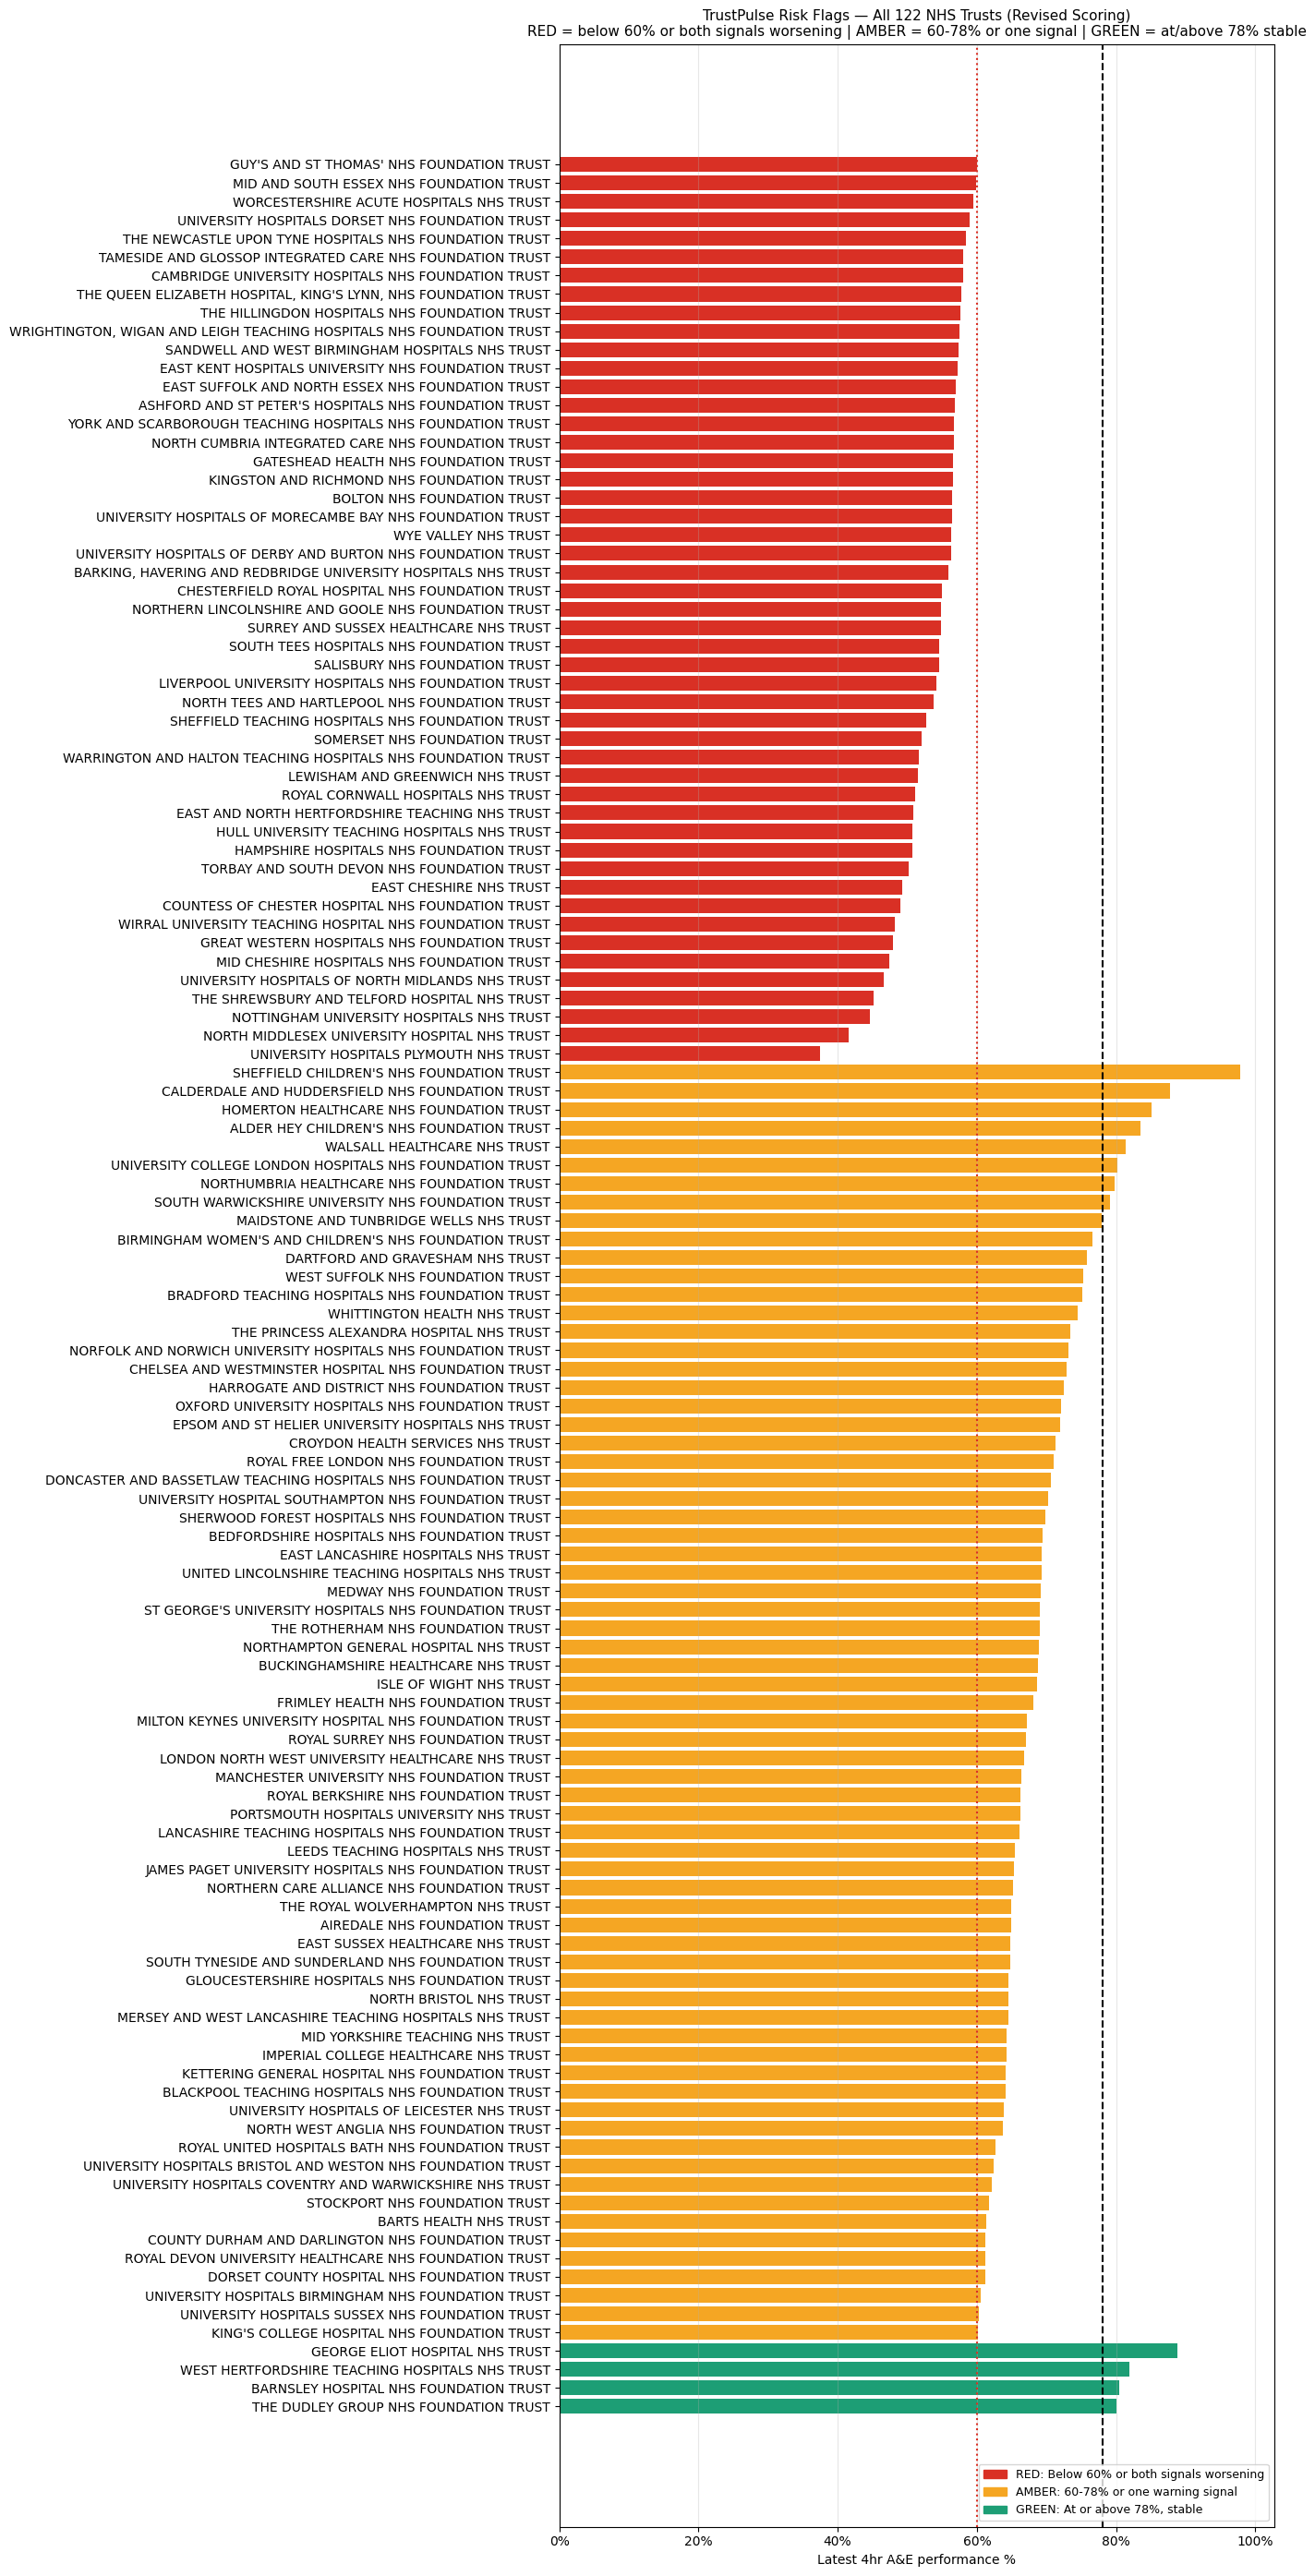

Chart saved.


In [8]:
# Redraw chart with revised risk flags
risk_df['flag_order'] = risk_df['risk_flag'].map({'RED': 0, 'AMBER': 1, 'GREEN': 2})
risk_sorted_all = risk_df.sort_values(['flag_order', 'latest_ae_perf_pct'], ascending=[False, True])

color_map = {'RED': '#d93025', 'AMBER': '#f5a623', 'GREEN': '#1d9e75'}
colors = [color_map[flag] for flag in risk_sorted_all['risk_flag']]

fig, ax = plt.subplots(figsize=(14, 28))
ax.barh(risk_sorted_all['org_name'], risk_sorted_all['latest_ae_perf_pct'], color=colors)

ax.axvline(x=78, color='black', linestyle='--', linewidth=1.5, label='78% NHS target')
ax.axvline(x=60, color='#d93025', linestyle=':', linewidth=1.5, label='60% RED threshold')

ax.set_title('TrustPulse Risk Flags — All 122 NHS Trusts (Revised Scoring)\n'
             'RED = below 60% or both signals worsening | '
             'AMBER = 60-78% or one signal | '
             'GREEN = at/above 78% stable',
             fontsize=11)
ax.set_xlabel('Latest 4hr A&E performance %')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

red_patch = mpatches.Patch(color='#d93025', label='RED: Below 60% or both signals worsening')
amber_patch = mpatches.Patch(color='#f5a623', label='AMBER: 60-78% or one warning signal')
green_patch = mpatches.Patch(color='#1d9e75', label='GREEN: At or above 78%, stable')
ax.legend(handles=[red_patch, amber_patch, green_patch], loc='lower right', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../static/chart_risk_flags.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")